In [1]:
# Import libraries and print TensorFlow version
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print(tf.__version__)

2.16.2


In [2]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    'data',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(224, 224),
    shuffle=True,
    validation_split=0.2,
    subset='training',
    seed=123
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    'data',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(224, 224),
    shuffle=True,
    validation_split=0.2,
    subset='validation',
    seed=123
)

Found 2671 files belonging to 5 classes.
Using 2137 files for training.
Using 2137 files for training.


2025-11-25 13:00:09.943970: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2025-11-25 13:00:09.944008: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-11-25 13:00:09.944020: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2025-11-25 13:00:09.944522: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-11-25 13:00:09.944542: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Found 2671 files belonging to 5 classes.
Using 534 files for validation.
Using 534 files for validation.


Class names: ['Bench Press', 'Dumbells', 'Elliptical Machine', 'Recumbent Bike', 'Smith Machine']
Class mapping:
0: Bench Press
1: Dumbells
2: Elliptical Machine
3: Recumbent Bike
4: Smith Machine


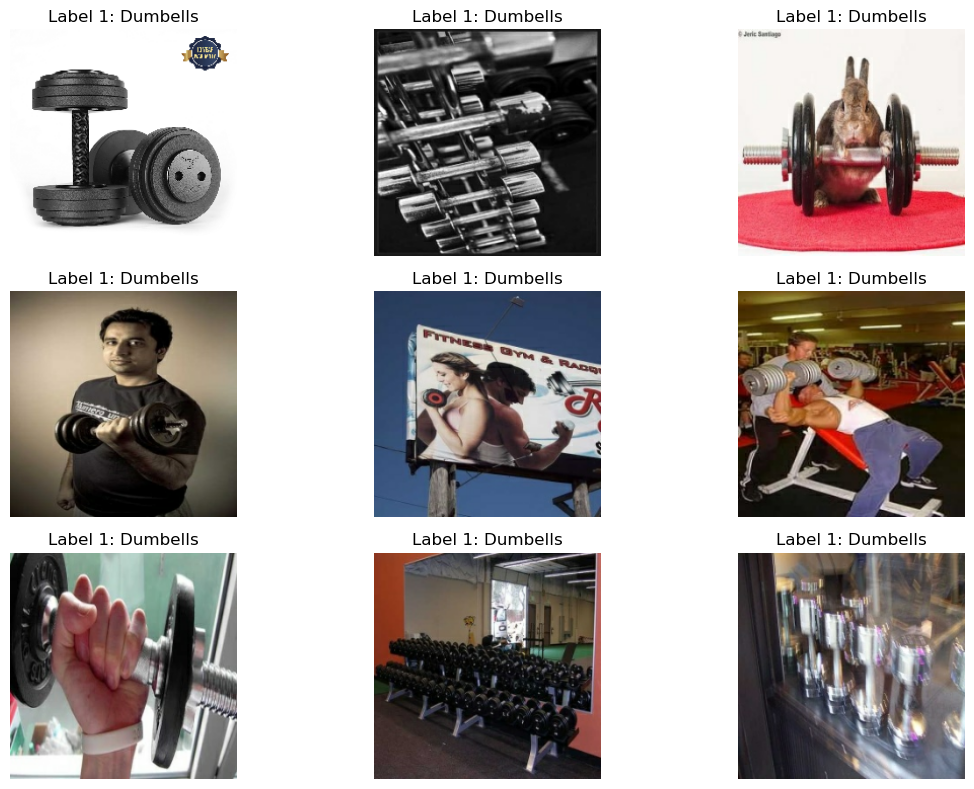

In [3]:
print("Class names:", train_ds.class_names)

print("Class mapping:")
for i, class_name in enumerate(train_ds.class_names):
    print(f"{i}: {class_name}")

plt.figure(figsize=(12, 8))
for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):  # Show up to 9 images
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        label_idx = labels[i].numpy()
        class_name = train_ds.class_names[label_idx]
        plt.title(f"Label {label_idx}: {class_name}")
        plt.axis('off')
    break
plt.tight_layout()
plt.show()

In [4]:
# Check pixel value ranges
for images, labels in train_ds.take(1):
    print(f"Image dtype: {images.dtype}")
    print(f"Min pixel value: {tf.reduce_min(images)}")
    print(f"Max pixel value: {tf.reduce_max(images)}")
    break

Image dtype: <dtype: 'float32'>
Min pixel value: 0.0
Max pixel value: 255.0


2025-11-25 13:00:12.378174: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile


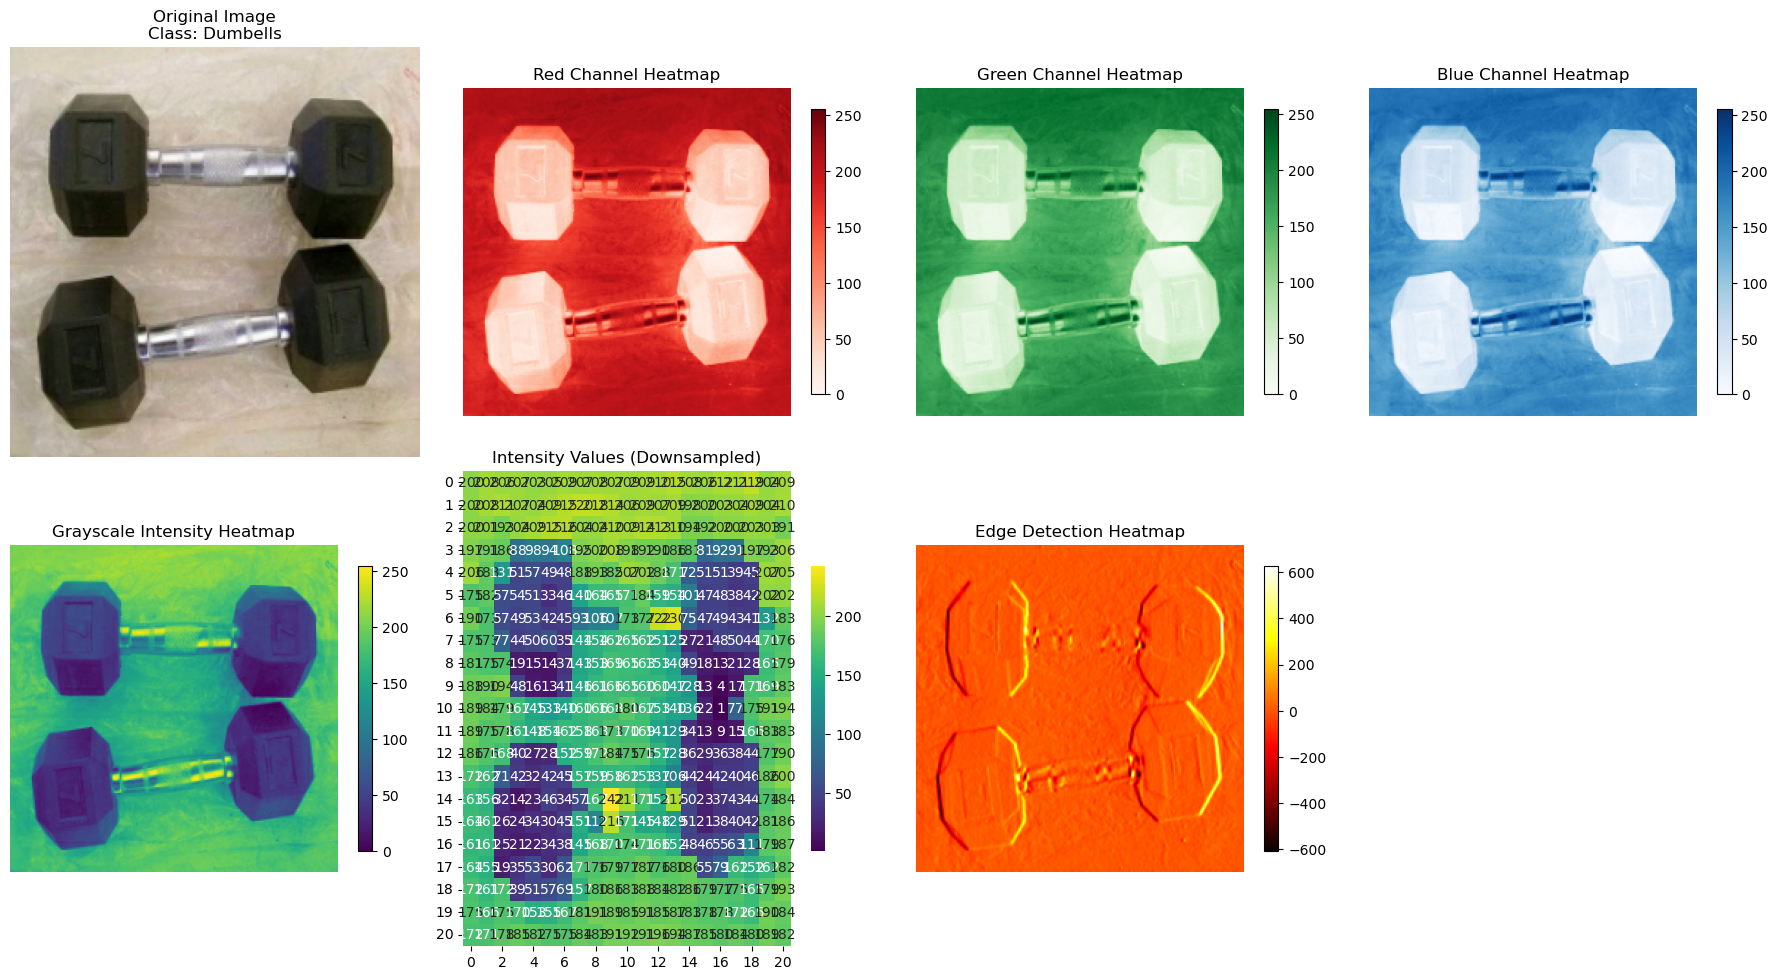


Image Statistics for Dumbells:
Shape: (224, 224, 3)
Min pixel value: 0
Max pixel value: 255
Mean pixel value: 135.81
Standard deviation: 67.51


In [5]:
# Create a heatmap visualization of a single image
import seaborn as sns

# Get a single image from the dataset
for images, labels in train_ds.take(1):
    # Take the first image from the batch
    single_image = images[0]
    label_idx = labels[0].numpy()
    class_name = train_ds.class_names[label_idx]
    
    # Convert to numpy for visualization
    img_array = single_image.numpy().astype('uint8')
    
    # Create subplots for different visualizations
    # We need 4 columns on the top row (original + 3 channels), so use 2x4 grid
    fig, axes = plt.subplots(2, 4, figsize=(18, 10))
    
    # Original image
    axes[0, 0].imshow(img_array)
    axes[0, 0].set_title(f'Original Image\nClass: {class_name}')
    axes[0, 0].axis('off')
    
    # RGB channel heatmaps
    channel_names = ['Red', 'Green', 'Blue']
    colors = ['Reds', 'Greens', 'Blues']
    
    for i in range(3):
        im = axes[0, i+1].imshow(img_array[:, :, i], cmap=colors[i])
        axes[0, i+1].set_title(f'{channel_names[i]} Channel Heatmap')
        axes[0, i+1].axis('off')
        plt.colorbar(im, ax=axes[0, i+1], shrink=0.6)
    
    # Grayscale intensity heatmap
    gray_image = np.mean(img_array, axis=2)  # Convert to grayscale
    im1 = axes[1, 0].imshow(gray_image, cmap='viridis')
    axes[1, 0].set_title('Grayscale Intensity Heatmap')
    axes[1, 0].axis('off')
    plt.colorbar(im1, ax=axes[1, 0], shrink=0.6)
    
    # Seaborn heatmap with values (downsampled for readability)
    # Downsample the image to 20x20 for better readability
    downsampled = gray_image[::max(1, gray_image.shape[0]//20), ::max(1, gray_image.shape[1]//20)]
    sns.heatmap(downsampled, annot=True, fmt='.0f', cmap='viridis', 
                ax=axes[1, 1], cbar_kws={'shrink': 0.6})
    axes[1, 1].set_title('Intensity Values (Downsampled)')
    
    # Edge detection heatmap (for fun)
    from scipy import ndimage
    edges = ndimage.sobel(gray_image)
    im2 = axes[1, 2].imshow(edges, cmap='hot')
    axes[1, 2].set_title('Edge Detection Heatmap')
    axes[1, 2].axis('off')
    plt.colorbar(im2, ax=axes[1, 2], shrink=0.6)
    
    # (axes[1,3] intentionally left empty)
    axes[1, 3].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Print some statistics
    print(f"\nImage Statistics for {class_name}:")
    print(f"Shape: {img_array.shape}")
    print(f"Min pixel value: {np.min(img_array)}")
    print(f"Max pixel value: {np.max(img_array)}")
    print(f"Mean pixel value: {np.mean(img_array):.2f}")
    print(f"Standard deviation: {np.std(img_array):.2f}")
    
    break

In [6]:
# Store class names before applying transformations
class_names = train_ds.class_names
num_classes = len(class_names)

print(f"Found {num_classes} classes: {class_names}")

# Normalize the datasets for better training performance
def normalize_img(image, label):
    return tf.cast(image, tf.float32) / 255.0, label

train_ds = train_ds.map(normalize_img, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.map(normalize_img, num_parallel_calls=tf.data.AUTOTUNE)

# Optimize dataset performance
train_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(tf.data.AUTOTUNE)

Found 5 classes: ['Bench Press', 'Dumbells', 'Elliptical Machine', 'Recumbent Bike', 'Smith Machine']


In [7]:
# Clean approach: manually create dataset with validation
import os
from pathlib import Path

def create_clean_dataset(data_dir, image_size=(224, 224), batch_size=32, validation_split=0.2, seed=123):
    """Create dataset with proper file validation"""
    
    # Valid image extensions
    valid_extensions = {'.jpg', '.jpeg', '.png', '.gif', '.bmp'}
    
    # Get all valid image files
    all_files = []
    labels = []
    class_names = []
    
    data_path = Path(data_dir)
    
    # Get class names from directory names
    for class_dir in sorted(data_path.iterdir()):
        if class_dir.is_dir():
            class_names.append(class_dir.name)
    
    print(f"Found classes: {class_names}")
    
    # Collect all valid image files
    for class_idx, class_name in enumerate(class_names):
        class_path = data_path / class_name
        class_files = []
        
        for img_file in class_path.iterdir():
            if img_file.is_file() and img_file.suffix.lower() in valid_extensions:
                # Quick check if file is readable
                try:
                    if img_file.stat().st_size > 0:  # File not empty
                        all_files.append(str(img_file))
                        labels.append(class_idx)
                        class_files.append(img_file.name)
                except:
                    print(f"Skipping problematic file: {img_file}")
        
        print(f"{class_name}: {len(class_files)} valid images")
    
    print(f"Total valid images: {len(all_files)}")
    
    # Create TensorFlow dataset
    def process_path(file_path, label):
        # Read and decode image
        image = tf.io.read_file(file_path)
        image = tf.image.decode_image(image, channels=3, expand_animations=False)
        image = tf.image.resize(image, image_size)
        image = tf.cast(image, tf.float32) / 255.0
        return image, label
    
    # Create dataset from file paths
    dataset = tf.data.Dataset.from_tensor_slices((all_files, labels))
    dataset = dataset.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
    
    # Shuffle and split
    dataset = dataset.shuffle(len(all_files), seed=seed)
    
    train_size = int(len(all_files) * (1 - validation_split))
    train_ds = dataset.take(train_size)
    val_ds = dataset.skip(train_size)
    
    # Batch and optimize
    train_ds = train_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    val_ds = val_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    
    return train_ds, val_ds, class_names

# Create clean datasets
print("Creating clean datasets...")
train_ds_clean, val_ds_clean, class_names_clean = create_clean_dataset('data')

# Update global variables
train_ds = train_ds_clean
val_ds = val_ds_clean
class_names = class_names_clean
num_classes = len(class_names)

Creating clean datasets...
Found classes: ['Bench Press', 'Dumbells', 'Elliptical Machine', 'Recumbent Bike', 'Smith Machine']
Bench Press: 61 valid images
Dumbells: 2042 valid images
Elliptical Machine: 353 valid images
Recumbent Bike: 167 valid images
Smith Machine: 48 valid images
Total valid images: 2671


In [8]:
# NUCLEAR OPTION: Find and remove all corrupted image files
import os
from pathlib import Path
import shutil

def find_and_remove_corrupted_images(data_dir):
    """Find and remove corrupted image files"""
    
    corrupted_files = []
    valid_extensions = {'.jpg', '.jpeg', '.png', '.gif', '.bmp'}
    
    data_path = Path(data_dir)
    
    print("Scanning all image files for corruption...")
    
    for class_dir in data_path.iterdir():
        if class_dir.is_dir():
            print(f"\nChecking {class_dir.name}...")
            class_corrupted = []
            
            for img_file in class_dir.iterdir():
                if img_file.is_file() and img_file.suffix.lower() in valid_extensions:
                    try:
                        # Try to read and decode with TensorFlow
                        img_data = tf.io.read_file(str(img_file))
                        decoded = tf.image.decode_image(img_data, channels=3, expand_animations=False)
                        
                        # Also check file size
                        if img_file.stat().st_size < 1000:  # Less than 1KB is suspicious
                            raise Exception("File too small")
                            
                    except Exception as e:
                        corrupted_files.append(img_file)
                        class_corrupted.append(img_file.name)
                        print(f"  CORRUPTED: {img_file.name} - {str(e)}")
            
            if class_corrupted:
                print(f"  Found {len(class_corrupted)} corrupted files in {class_dir.name}")
            else:
                print(f"  ✓ All files in {class_dir.name} are valid")
    
    if corrupted_files:
        print(f"\n🚨 FOUND {len(corrupted_files)} CORRUPTED FILES!")
        print("\nRemoving corrupted files...")
        
        for bad_file in corrupted_files:
            try:
                bad_file.unlink()  # Delete the file
                print(f"  Removed: {bad_file}")
            except Exception as e:
                print(f"  Failed to remove {bad_file}: {e}")
        
        print(f"\n✅ Removed {len(corrupted_files)} corrupted files")
    else:
        print("\n✅ No corrupted files found!")
    
    return len(corrupted_files)

# Run the corruption check and cleanup
removed_count = find_and_remove_corrupted_images('data')

Scanning all image files for corruption...

Checking Recumbent Bike...
  ✓ All files in Recumbent Bike are valid

Checking Bench Press...
  ✓ All files in Bench Press are valid

Checking Dumbells...
  ✓ All files in Recumbent Bike are valid

Checking Bench Press...
  ✓ All files in Bench Press are valid

Checking Dumbells...


2025-11-25 13:00:14.821683: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile


  ✓ All files in Dumbells are valid

Checking Elliptical Machine...
  ✓ All files in Elliptical Machine are valid

Checking Smith Machine...
  ✓ All files in Smith Machine are valid

✅ No corrupted files found!
  ✓ All files in Elliptical Machine are valid

Checking Smith Machine...
  ✓ All files in Smith Machine are valid

✅ No corrupted files found!


In [9]:
# Create MobileNetV2 base model (pretrained on ImageNet)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    alpha=1.0,  # Width multiplier (1.0 = standard width)
    include_top=False,  # Don't include final classification layer
    weights='imagenet'  # Use pretrained ImageNet weights
)

# Freeze the base model layers for transfer learning
base_model.trainable = False

print(f"Number of layers in base model: {len(base_model.layers)}")
print(f"Base model output shape: {base_model.output.shape}")
print(f"Number of classes in your dataset: {num_classes}")

Number of layers in base model: 154
Base model output shape: (None, 7, 7, 1280)
Number of classes in your dataset: 5


In [10]:
# Build the complete model with MobileNetV2 + custom classifier
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Print model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [11]:
# Train the model (initial training with frozen base)
initial_epochs = 10

# Use the clean datasets created in cell 7
history = model.fit(
    train_ds_clean,
    epochs=initial_epochs,
    validation_data=val_ds_clean,
    verbose=1
)

Epoch 1/10


2025-11-25 13:00:20.711226: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2025-11-25 13:00:21.946548: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-11-25 13:00:21.946548: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile


67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.4754 - loss: 1.3631

2025-11-25 13:00:30.894775: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile


67/67 ━━━━━━━━━━━━━━━━━━━━ 15s 157ms/step - accuracy: 0.6199 - loss: 1.0965 - val_accuracy: 0.7514 - val_loss: 0.7299
Epoch 2/10
Epoch 2/10


...

67/67 ━━━━━━━━━━━━━━━━━━━━ 11s 125ms/step - accuracy: 0.9448 - loss: 0.1780 - val_accuracy: 0.9776 - val_loss: 0.1280
Epoch 10/10
Epoch 10/10


2025-11-25 13:01:59.906035: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile


67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9639 - loss: 0.1458

2025-11-25 13:02:06.870137: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile


67/67 ━━━━━━━━━━━━━━━━━━━━ 10s 121ms/step - accuracy: 0.9541 - loss: 0.1552 - val_accuracy: 0.9738 - val_loss: 0.1303


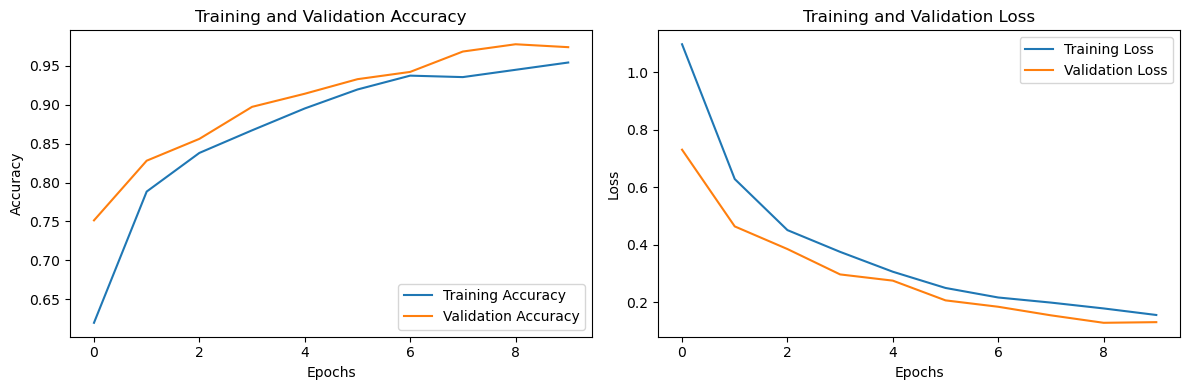

In [12]:
# Plot training history
def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    
    epochs_range = range(len(acc))
    
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    
    plt.tight_layout()
    plt.show()

plot_training_history(history)

In [13]:
# Fine-tuning: Unfreeze the top layers of MobileNetV2 for better performance
base_model.trainable = True

# Fine-tune from this layer onwards
fine_tune_at = 100  # Unfreeze the last 54 layers (154 total - 100)

# Freeze all the layers before fine_tune_at
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Use a lower learning rate for fine-tuning
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001/10),  # 10x lower learning rate
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print(f"Total layers: {len(base_model.layers)}")
print(f"Trainable layers: {sum([1 for layer in base_model.layers if layer.trainable])}")

Total layers: 154
Trainable layers: 54


In [14]:
# Continue training with fine-tuning
fine_tune_epochs = 10
total_epochs = initial_epochs + fine_tune_epochs

history_fine = model.fit(
    train_ds_clean,
    epochs=total_epochs,
    initial_epoch=history.epoch[-1],
    validation_data=val_ds_clean,
    verbose=1
)

Epoch 10/20


2025-11-25 13:02:15.368094: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile


67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - accuracy: 0.9020 - loss: 0.2850

2025-11-25 13:02:40.499509: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile


67/67 ━━━━━━━━━━━━━━━━━━━━ 35s 355ms/step - accuracy: 0.9251 - loss: 0.2373 - val_accuracy: 0.9776 - val_loss: 0.0989
Epoch 11/20
Epoch 11/20


...

67/67 ━━━━━━━━━━━━━━━━━━━━ 20s 267ms/step - accuracy: 0.9949 - loss: 0.0268 - val_accuracy: 0.9925 - val_loss: 0.0240
Epoch 20/20
Epoch 20/20


2025-11-25 13:05:59.168419: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile


67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 0.9970 - loss: 0.0239

2025-11-25 13:06:15.415203: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile


67/67 ━━━━━━━━━━━━━━━━━━━━ 20s 264ms/step - accuracy: 0.9949 - loss: 0.0277 - val_accuracy: 1.0000 - val_loss: 0.0153


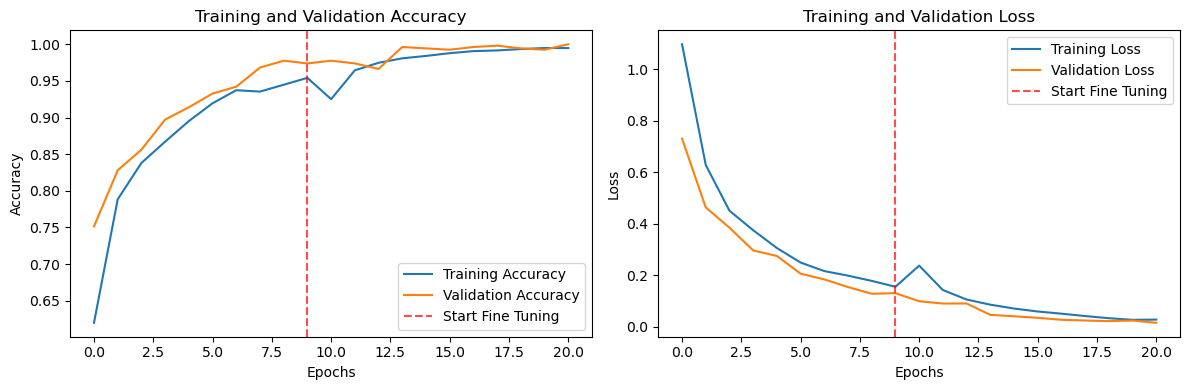

In [15]:
# Plot the complete training history (initial + fine-tuning)
def plot_complete_history(hist1, hist2):
    # Combine histories
    acc = hist1.history['accuracy'] + hist2.history['accuracy']
    val_acc = hist1.history['val_accuracy'] + hist2.history['val_accuracy']
    loss = hist1.history['loss'] + hist2.history['loss']
    val_loss = hist1.history['val_loss'] + hist2.history['val_loss']
    
    epochs_range = range(len(acc))
    
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.axvline(x=len(hist1.history['accuracy'])-1, color='r', linestyle='--', alpha=0.7, label='Start Fine Tuning')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.axvline(x=len(hist1.history['loss'])-1, color='r', linestyle='--', alpha=0.7, label='Start Fine Tuning')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    
    plt.tight_layout()
    plt.show()

plot_complete_history(history, history_fine)

2025-11-25 13:06:19.239064: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile


17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 209ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 209ms/step


2025-11-25 13:06:27.642887: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile


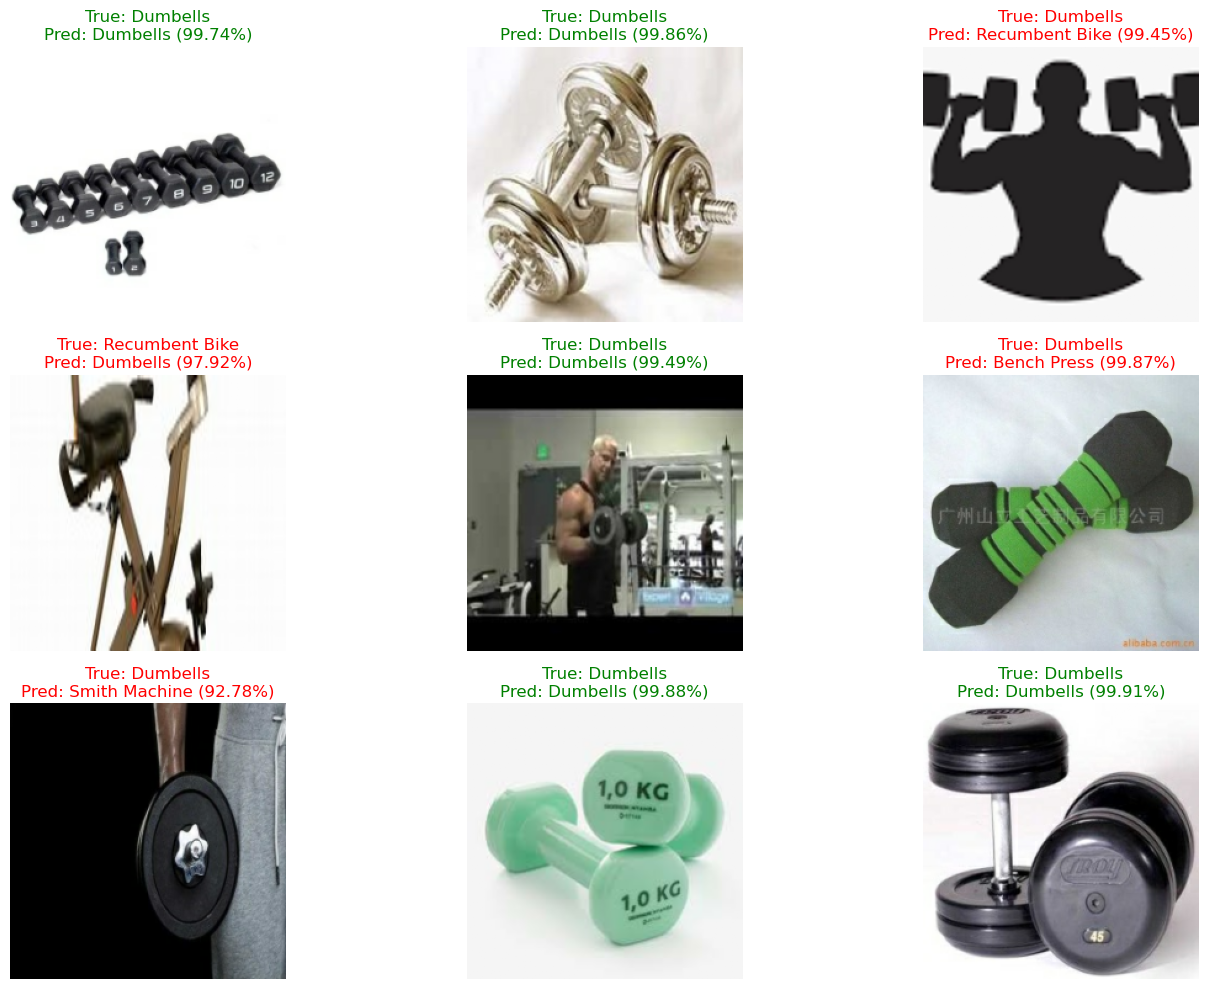

In [16]:
# Evaluate the model and make predictions
def evaluate_and_predict(model, dataset, class_names, num_samples=9):
    # Get predictions for visualization
    predictions = model.predict(dataset)
    
    # Visualize some predictions
    plt.figure(figsize=(15, 10))
    
    batch_count = 0
    image_count = 0
    
    for images, labels in dataset.take(10):  # Take several batches
        for i in range(len(images)):
            if image_count >= num_samples:
                break
                
            img = images[i].numpy()
            true_label = labels[i].numpy()
            
            # Get prediction for this specific image
            pred_probs = predictions[batch_count * 32 + i]  # Assuming batch_size=32
            pred_label = np.argmax(pred_probs)
            confidence = np.max(pred_probs)
            
            plt.subplot(3, 3, image_count + 1)
            plt.imshow(img)
            
            # Color code: green for correct, red for incorrect
            color = 'green' if pred_label == true_label else 'red'
            plt.title(f'True: {class_names[true_label]}\n'
                     f'Pred: {class_names[pred_label]} ({confidence:.2%})', 
                     color=color)
            plt.axis('off')
            
            image_count += 1
            
        batch_count += 1
        if image_count >= num_samples:
            break
    
    plt.tight_layout()
    plt.show()

# Run evaluation
evaluate_and_predict(model, val_ds_clean, class_names_clean)